In [1]:
import os
from pathlib import Path

# Check what files exist
data_dir = Path('..') / 'data'
print("Data dir exists:", data_dir.exists())
print("\nFiles in data/:")
for f in data_dir.rglob('*'):
    print(f)

Data dir exists: True

Files in data/:
..\data\raw
..\data\raw\processed
..\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
..\data\raw\processed\telco_churn_clean_v2.csv
..\data\raw\processed\telco_churn_processed.csv
..\data\raw\processed\telco_churn_uplift_ready.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from pathlib import Path

# Portable path — works on any machine
DATA_DIR = Path('..') / 'data' / 'raw'

df = pd.read_csv(DATA_DIR / 'processed' / 'telco_churn_clean_v2.csv')

print("Original shape:", df.shape)
print("\nChurn distribution in full data:")
print(df['Churn'].value_counts(normalize=True).round(4) * 100)

# ----- Cell 3: Prepare X and y -----
# All columns except Churn are features
X = df.drop(columns=['Churn'])
y = df['Churn']   # 0 = stay, 1 = churn (assuming it's already 0/1)

# ----- Cell 4: Do the split -----
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,          # 20% for testing
    stratify=y,              # keep churn % similar in both
    random_state=42          # magic number that makes split repeatable
)

# ----- Cell 5: Quick quality check -----
print("\n=== After split ===")
print(f"Train shape: {X_train.shape} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test shape:  {X_test.shape}  ({len(X_test)/len(df)*100:.1f}%)")

print("\nChurn % in train:")
print(y_train.value_counts(normalize=True).round(4) * 100)

print("\nChurn % in test:")
print(y_test.value_counts(normalize=True).round(4) * 100)

Original shape: (7043, 24)

Churn distribution in full data:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

=== After split ===
Train shape: (5634, 23) (80.0%)
Test shape:  (1409, 23)  (20.0%)

Churn % in train:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Churn % in test:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


## Step 2: Build & Evaluate Basic Churn Predictor Models

In [3]:
# ----- Cell: Imports for modeling -----
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

# ----- Cell: Define paths & load (you already did this, just for safety) -----
from pathlib import Path
DATA_DIR = Path('..') / 'data' / 'raw' / 'processed'
df = pd.read_csv(DATA_DIR / 'telco_churn_clean_v2.csv')

# We already have X_train, X_test, y_train, y_test from Step 1
# If you restarted kernel → re-run the split code first

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (5634, 23) Test shape: (1409, 23)


In [4]:
# ----- Cell 2.1: Identify numeric and categorical columns -----
# Numeric columns (should be scaled)
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 
                    'TotalServices', 'Recency_score', 'Frequency_score', 'Monetary_score']

# Categorical columns (one-hot encoding)
categorical_features = [col for col in X_train.columns 
                        if col not in numeric_features and col != 'Churn']

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'Recency_score', 'Frequency_score', 'Monetary_score']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [5]:
# ----- Cell 2.2: Create preprocessing + model pipeline -----
# Preprocessing for all columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# ----- Logistic Regression Pipeline (with SMOTE) -----
lr_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# ----- XGBoost Pipeline (with SMOTE) -----
xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
    eval_metric='auc',
    random_state=42,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1
))
])

In [6]:
# ----- Cell 2.3: Train both models -----
print("Training Logistic Regression...")
lr_pipeline.fit(X_train, y_train)

print("Training XGBoost...")
xgb_pipeline.fit(X_train, y_train)

print("Both models trained!")

Training Logistic Regression...
Training XGBoost...
Both models trained!



=== Logistic Regression Results ===
ROC-AUC: 0.8399


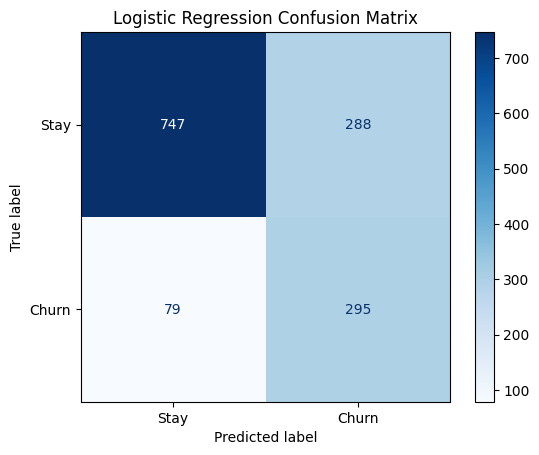


=== XGBoost Results ===
ROC-AUC: 0.8373


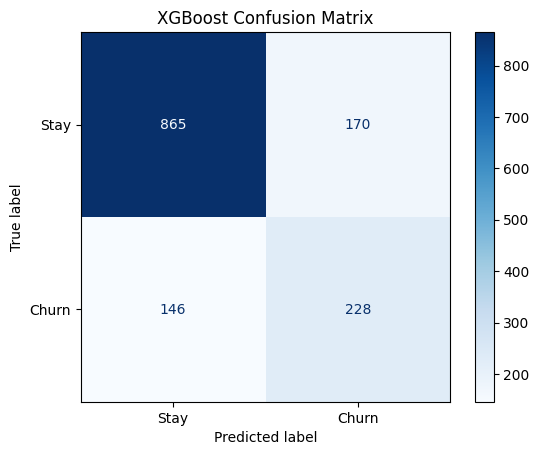


Comparison:
Logistic Regression AUC: 0.8399
XGBoost AUC:           0.8373
Winner: Logistic Regression


In [7]:
# ----- Cell 2.4: Evaluate on TEST set -----
def evaluate_model(pipeline, name):
    # Predict probabilities
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"\n=== {name} Results ===")
    print(f"ROC-AUC: {auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Churn'])
    disp.plot(cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()
    
    return auc

# Run evaluation
lr_auc = evaluate_model(lr_pipeline, "Logistic Regression")
xgb_auc = evaluate_model(xgb_pipeline, "XGBoost")

print("\nComparison:")
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"XGBoost AUC:           {xgb_auc:.4f}")
print(f"Winner: {'XGBoost' if xgb_auc > lr_auc else 'Logistic Regression'}")

In [8]:
# ----- Imports for Step 3 -----
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ----- Reload data & split (quick safety) -----
# Use your actual path
from pathlib import Path
df = pd.read_csv(Path('..') / 'data' / 'raw' / 'processed' / 'telco_churn_clean_v2.csv')
df = pd.get_dummies(df, drop_first=True)
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Data reloaded. Train shape:", X_train.shape)

Data reloaded. Train shape: (5634, 34)


In [9]:
# ----- Train the winning model again (Logistic Regression) -----
model_lr = LogisticRegression(
    solver='liblinear',          # good for small/medium data
    max_iter=1000,
    random_state=42,
    class_weight='balanced'      # helps with imbalance
)

model_lr.fit(X_train, y_train)

# Quick check AUC again
preds_proba = model_lr.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, preds_proba)
print(f"Logistic Regression AUC on test: {auc:.4f}")

Logistic Regression AUC on test: 0.8428


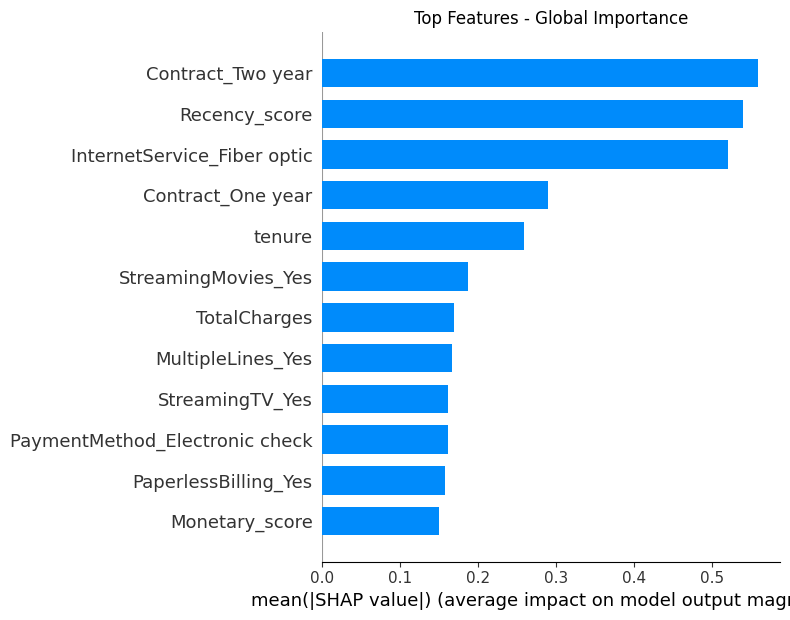

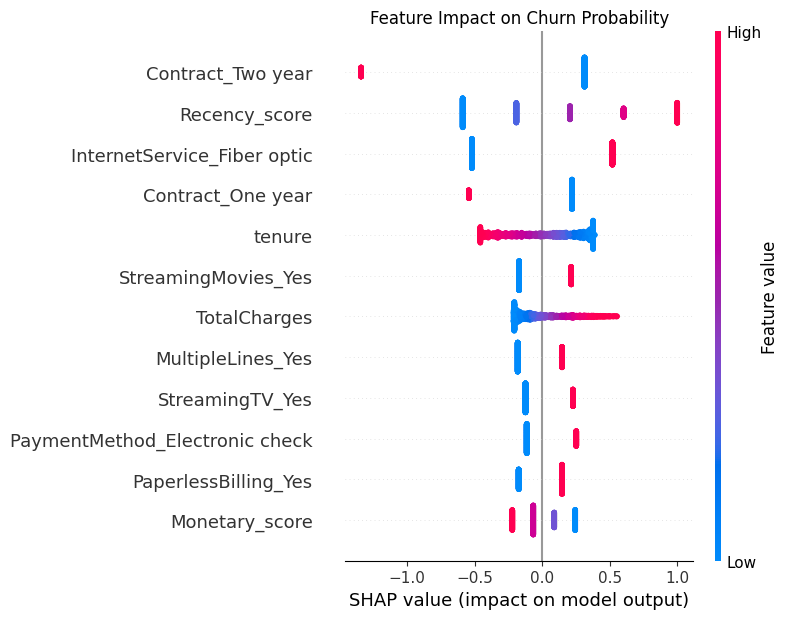

In [10]:
# ----- SHAP Time! -----
# Create SHAP explainer for logistic regression
explainer = shap.Explainer(model_lr, X_train, model_output="probability")

# Calculate SHAP values (this can take 1–3 minutes first time)
shap_values = explainer(X_test)
shap_vals_array = np.array(shap_values.values, dtype=np.float64)
feature_names = X_test.columns.tolist()

# ----- 1. Summary plot – global importance -----
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_array, X_test, plot_type="bar", max_display=12, feature_names=feature_names, show=False)
plt.title("Top Features - Global Importance")
plt.tight_layout()
plt.show()

# ----- 2. Beeswarm plot – how features push prediction -----
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_array, X_test, plot_type="dot", max_display=12, feature_names=feature_names, show=False)
plt.title("Feature Impact on Churn Probability")
plt.tight_layout()
plt.show()

High-risk example – index 1090
Actual churn: 1
Predicted probability: 0.9502


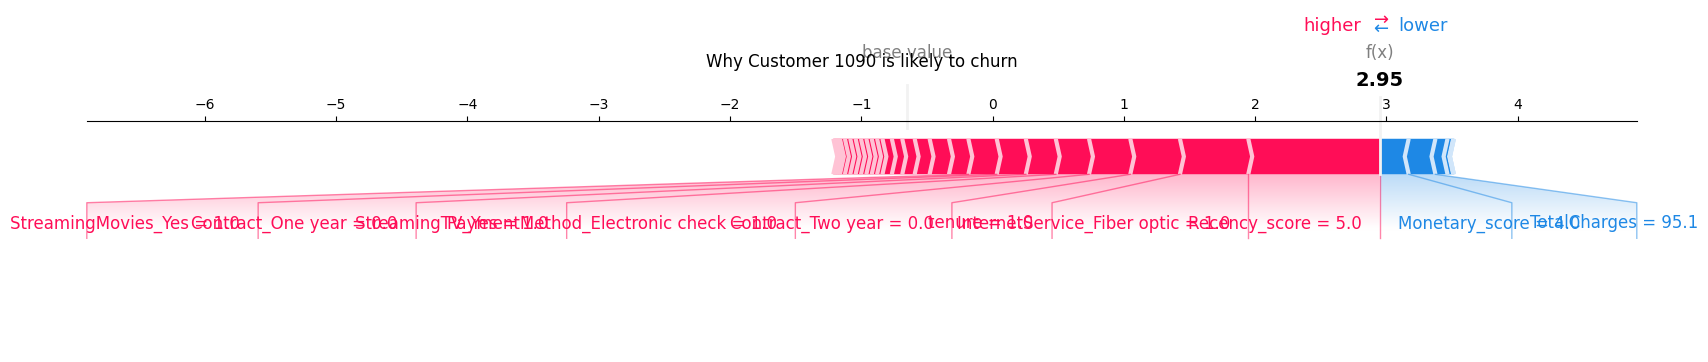

In [11]:
# ----- 3. Explain ONE customer (example: high risk one) -----
# Pick the customer with highest predicted churn probability
idx_high_risk = np.argmax(preds_proba)

print(f"High-risk example – index {idx_high_risk}")
print("Actual churn:", y_test.iloc[idx_high_risk])
print("Predicted probability:", preds_proba[idx_high_risk].round(4))

# FIX: Extract raw values from the SHAP Explanation object
# .values gets the matrix, [idx] gets the specific row
single_shap_values = shap_values.values[idx_high_risk]
base_value = explainer.expected_value
feature_data = X_test.iloc[idx_high_risk]

# Force plot
shap.force_plot(
    base_value, 
    single_shap_values, 
    feature_data, 
    matplotlib=True, 
    show=False
)

plt.title(f"Why Customer {idx_high_risk} is likely to churn", y=1.2) # Adjust title height
plt.show()

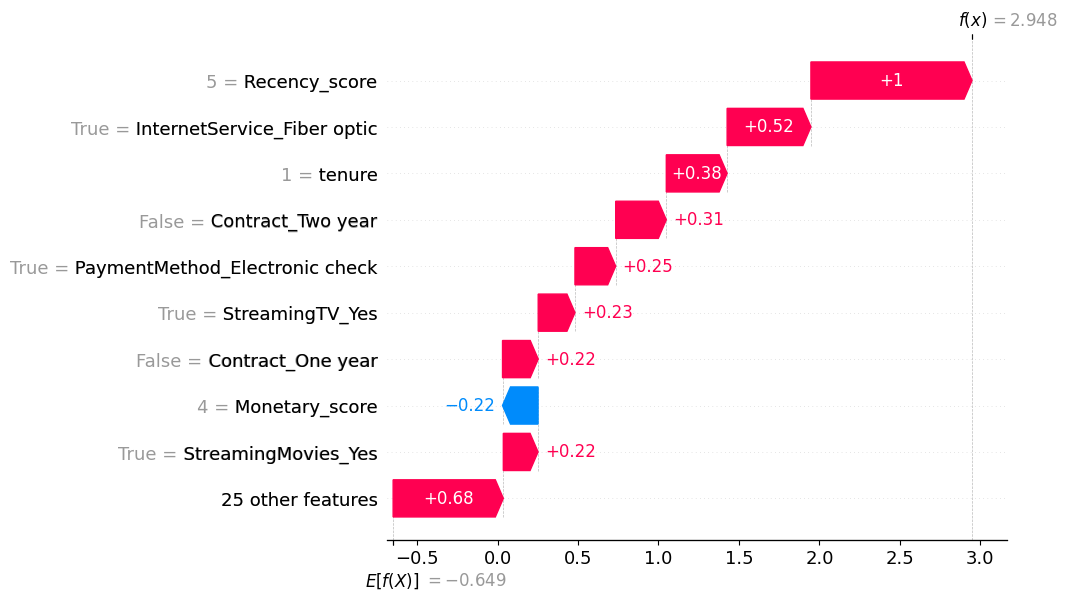

In [12]:
# ----- Optional: Waterfall plot for the same customer -----
shap.plots.waterfall(shap_values[idx_high_risk], max_display=10)


In [13]:
import joblib
from pathlib import Path

# Create models directory
MODELS_DIR = Path('..') / 'models'
MODELS_DIR.mkdir(exist_ok=True)

# Save both pipelines
joblib.dump(xgb_pipeline, MODELS_DIR / 'xgb_pipeline.pkl')
joblib.dump(lr_pipeline,  MODELS_DIR / 'lr_pipeline.pkl')
joblib.dump(model_lr,     MODELS_DIR / 'model_lr.pkl')

print("Saved:")
print(f"  models/xgb_pipeline.pkl")
print(f"  models/lr_pipeline.pkl")
print(f"  models/model_lr.pkl")
print(f"\nModels dir: {MODELS_DIR.resolve()}")

Saved:
  models/xgb_pipeline.pkl
  models/lr_pipeline.pkl
  models/model_lr.pkl

Models dir: C:\Users\Poorva\OneDrive\Desktop\Documents\GitHub\Customer-Churn-Uplift-Model\models
